# Monte Carlo estimation for delta hedge dynamics within the BSM frame
**Category: Mathematics For New Technologies in Finance**

## Setup

Two assets $S_t,B_t$ with the following dynamics:

$$
S_t = S_0 \exp((r-1/2 \cdot\sigma^2)t+\sigma W^{\mathbb{Q}}_t)
$$

$$
B_t = B_0 \exp(rt)
$$

and the a european call as the contract, hence 
$$
v(t,S_t) = S_t \Phi(d_1(t,S_t))-K\exp(-(T-t)r)\Phi(d_2(t,S_t))
$$

and the first spatial derivative:
$$
\partial_s v(t,S_t) = \Phi(d_1(t,S_t)),
$$
second spatial derivative:
$$
\partial_{ss} v(t,S_t) = \varphi(d_1(t,S_t))\left(\frac{1}{S_t \sigma \sqrt{T-t}} \right),
$$
the time derivative:
$$
\partial_t v(t,S_t) = -S_t\varphi(d_1(t,S_t))\left(\frac{1}{2}\frac{\sigma}{ \sqrt{T-t}}\right) - rK \exp(-r(T-t))\Phi(d_2(t,S_t))
$$


Portfolio 1: $X_t = \eta^1_t S_t + \eta^2_t B_t = v(t,S_t)$

Portfolio 2: $\Pi_t = v(t,S_t)-\eta^1_t S_t$

And we note that:
$$
\eta^1_t = \Phi(d_1(t,S_t)), \quad \eta^2_t = \frac{1}{B_t r}\left(\partial_t v(t,S_t) + \frac{1}{2} \partial_{ss} v(t,S_t)\sigma^2 S_t^2\right)
$$



In [229]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stat
def gen_Bmotion(T,M,N):
    
    dt = T/M
    W = np.zeros(shape=(M+1,N))
    for i in range(1,M+1):
        W[i,:] = W[i-1]+np.sqrt(dt)*np.random.normal(0,1,size=N)

    return np.linspace(0,T,num=M+1),W

def gen_StockPath(S0,r,sigma,W,t):
    S = S0*np.exp(((r-0.5*sigma**2)*t)[:,None]+sigma*W)
    return S

def gen_CallPath(S,K):
    return np.maximum(S-K,0)

def d(S,K,r,sigma,t,T):
    tau = (T-t[:-1])[:,None]
    d1 = (np.log(S[:-1,:]/K)+(r+0.5*sigma**2)*tau)/(sigma*np.sqrt(tau))
    d2 = d1-sigma*np.sqrt(tau)

    return d1,d2

def B_t(r,t):
    return np.exp(r*t)

def v(S,C,K,d1,d2,r,t,T):
    tau = (T-t[:-1])[:,None]

    return np.vstack([S[:-1,:]*stat.norm.cdf(d1)-K*np.exp(-(tau)*r)*stat.norm.cdf(d2),C[-1,:]])

def delta(d1):
    return stat.norm.cdf(d1)

def gamma(S,d1,sigma,t,T):
    tau = (T-t[:-1])[:,None]

    return stat.norm.pdf(d1)*(1/(S[:-1,:]*sigma*tau))

    
def theta(S,K,d1,d2,r,sigma,t,T):
    tau = (T-t[:-1])[:,None]

    return -S[:-1,:]*stat.norm.pdf(d1)*(0.5*sigma/(tau))-r*K*np.exp(-r*tau)*stat.norm.cdf(d2)

def eta1(delta_):
    return delta_

def eta2(S,B,r,gamma,theta,sigma):
    return (theta+0.5*sigma**2*S[:-1,:]**2*gamma)/(B[:-1]*r)[:,None]


In [262]:
S0 = 100; K = 130; T = 5; r = 0.03; sigma = 0.35; N = 1000
M = 1000

t,W = gen_Bmotion(T,M,N)
S = gen_StockPath(S0,r,sigma,W,t)
C = gen_CallPath(S,K)

d1,d2 = d(S,K,r,sigma,t,T)
B = B_t(r,t)
v_mc = v(S,C,K,d1,d2,r,t,T)
delta_ = delta(d1)
gamma_ = gamma(S,d1,sigma,t,T)
theta_ = theta(S,K,d1,d2,r,sigma,t,T)

eta1_ = np.mean(eta1(delta_)[0,:])
eta2_ = np.mean(eta2(S,B,r,gamma_,theta_,sigma)[0,:])
X_t = eta1_*S[:-1,:]+eta2_*B[:-1,None]
Pi_t = v_mc[:-1,:]-eta1_*S[:-1]




In [263]:
rebalance_idx = np.linspace(0, M-1, 5, dtype=int)

eta1_semi = np.zeros_like(delta_)
eta2_semi = np.zeros_like(delta_)

eta2_full = eta2(S, B, r, gamma_, theta_, sigma)

for i, start in enumerate(rebalance_idx):
    end = rebalance_idx[i+1] if i+1 < len(rebalance_idx) else M
    eta1_semi[start:end, :] = delta_[start, :]
    eta2_semi[start:end, :] = eta2_full[start, :]

X_t_semi = eta1_semi * S[:-1, :] + eta2_semi * B[:-1, None]
Pi_t_semi = v_mc[:-1, :] - eta1_semi * S[:-1, :]

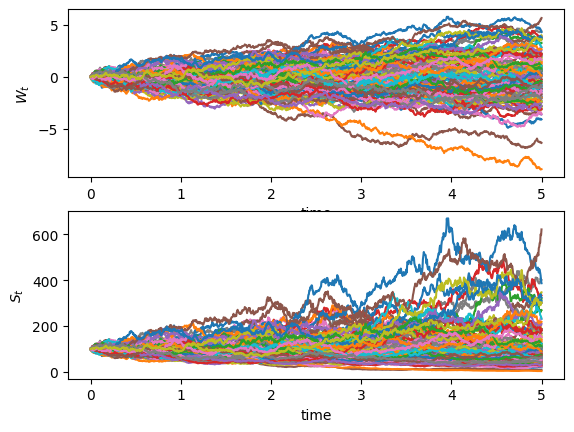

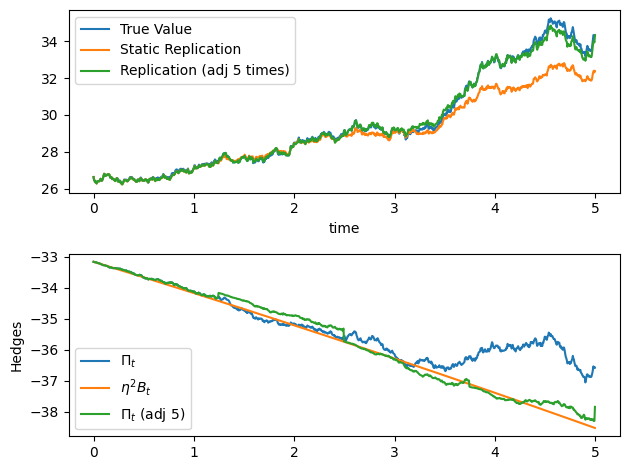

In [266]:
plt.subplot(2,1,1)
plt.plot(t,W[:,1:100])
plt.ylabel(fr"$W_t$")
plt.xlabel("time")
plt.subplot(2,1,2)
plt.plot(t,S[:,1:100])
plt.ylabel(fr"$S_t$")
plt.xlabel("time")
plt.show()

plt.subplot(2,1,1)
plt.plot(t[:-1],np.mean(v_mc,axis=1)[:-1],label="True Value")
plt.plot(t[:-1],np.mean(X_t,axis=1),label="Static Replication")
plt.plot(t[:-1],np.mean(X_t_semi,axis=1),label="Replication (adj 5 times)")

plt.xlabel("time")
plt.legend()
plt.subplot(2,1,2)
plt.plot(t[:-1],np.mean(Pi_t,axis=1),label=fr"$\Pi_t$")
plt.plot(t[:-1],np.mean(eta2_*B[:-1,None],axis=1),label=fr"$\eta^2 B_t$")
plt.plot(t[:-1],np.mean(Pi_t_semi,axis=1),label=fr"$\Pi_t$ (adj 5)")

plt.ylabel("Hedges")
plt.legend()
plt.tight_layout()
plt.show()


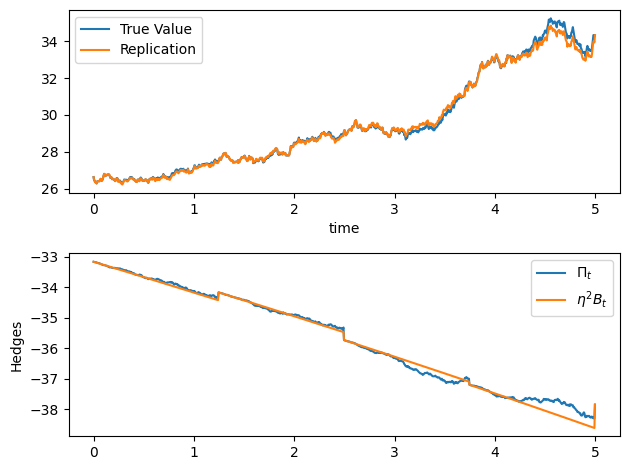

In [267]:
plt.subplot(2,1,1)
plt.plot(t[:-1],np.mean(v_mc,axis=1)[:-1],label="True Value")
plt.plot(t[:-1],np.mean(X_t_semi,axis=1),label="Replication")
plt.legend()
plt.xlabel("time")
plt.subplot(2,1,2)
plt.plot(t[:-1],np.mean(Pi_t_semi,axis=1),label=fr"$\Pi_t$")
plt.plot(t[:-1],np.mean(eta2_semi*B[:-1,None],axis=1),label=fr"$\eta^2 B_t$")
plt.ylabel("Hedges")
plt.legend()
plt.tight_layout()
plt.show()